In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,roc_auc_score

from sklearn.preprocessing import  LabelEncoder,OneHotEncoder,StandardScaler,TargetEncoder

In [2]:
df = pd.read_csv(r'Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# exploratory Data analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
print(df.duplicated().sum())

0


In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

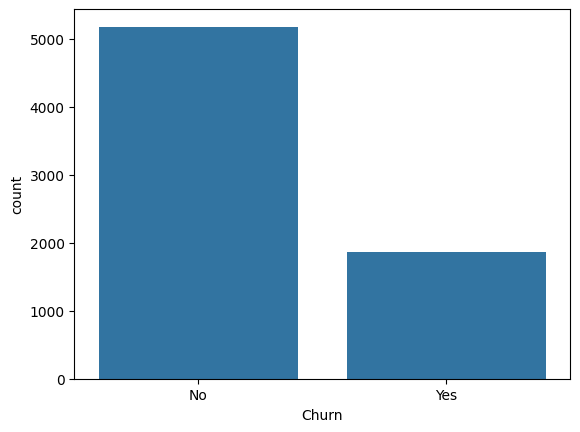

In [8]:
sns.countplot(x='Churn',data=df)

In [9]:
df['DeviceProtection'].value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [10]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
encoder = OneHotEncoder()

In [13]:

encoded_data = encoder.fit_transform(df[['DeviceProtection','InternetService','StreamingTV','StreamingMovies','PaymentMethod','OnlineSecurity','OnlineBackup','MultipleLines','InternetService','DeviceProtection','Contract',]])

In [14]:
encoded_dataa = pd.DataFrame(encoded_data.toarray(),columns=encoder.get_feature_names_out())
encoded_dataa

,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,...,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
7039,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
7040,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7041,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [15]:
df = df.reset_index(drop=True)
encodeing_dataa = encoded_dataa.reset_index(drop=True)

df = df.drop(['DeviceProtection','InternetService','StreamingTV','StreamingMovies','PaymentMethod','OnlineSecurity','OnlineBackup','MultipleLines','InternetService','DeviceProtection','Contract'],axis=1)
df = pd.concat([df,encoded_dataa],axis=1)

In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,TechSupport,PaperlessBilling,MonthlyCharges,...,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year
0,7590-VHVEG,Female,0,Yes,No,1,No,No,Yes,29.85,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,No,56.95,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,Yes,53.85,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,7795-CFOCW,Male,0,No,No,45,No,Yes,No,42.30,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Yes,70.70,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [17]:
df['TotalCharges'].describe()

count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object

In [18]:
import numpy as np

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df['TotalCharges'] = df['TotalCharges'].astype('float')

In [19]:
df['TotalCharges'].dtype

dtype('float64')

In [20]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [21]:
df = df.dropna()

In [22]:
le = LabelEncoder()


In [23]:
cat_cols = [
  'gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'TechSupport',
  'PaperlessBilling',
  'Churn'
]

for col in cat_cols :
  df[col] = le.fit_transform(df[col])


In [24]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,TechSupport,PaperlessBilling,MonthlyCharges,...,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year
0,7590-VHVEG,0,0,1,0,1,0,0,1,29.85,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,5575-GNVDE,1,0,0,0,34,1,0,0,56.95,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,3668-QPYBK,1,0,0,0,2,1,0,1,53.85,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,7795-CFOCW,1,0,0,0,45,0,2,0,42.30,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,9237-HQITU,0,0,0,0,2,1,0,1,70.70,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [25]:
df['Churn'].unique()

array([0, 1])

In [26]:
df['Churn'].dtype

dtype('int64')

In [27]:
x = df.drop(['Churn','customerID'],axis=1)
y = df['Churn']

In [28]:
x_train,x_test,y_train,y_test = train_test_split(
  x,y, test_size=0.2 ,random_state= 42 
)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 44)
(1407, 44)
(5625,)
(1407,)


In [29]:
# now we handle inbalanced data using smote 

In [30]:
# now we downlaod imbalanced-learn in this terminal 
# we check path of python using this command
import sys
print(sys.executable)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\python.exe


In [31]:
import sys
# !{sys.executable} -m pip install imbalanced-learn

In [32]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
x_train_sm,y_train_sm = sm.fit_resample(x_train,y_train)

In [33]:
# now we will apply algorithm 

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import  DecisionTreeClassifier
from sklearn.ensemble import  RandomForestClassifier

In [35]:
models = {
  'logistic regression' : LogisticRegression(),
  'RandomForestClassifier':RandomForestClassifier(),
  'DecisionTreeClassifier':DecisionTreeClassifier()
}

In [36]:
for name, model in models.items():
  model.fit(x_train_sm,y_train_sm)

  y_pred = model.predict(x_test)

  acc = accuracy_score(y_test,y_pred)
  print("accuracy_score",name,acc)
  
  print("----------------------------------------------")
  f1 = f1_score(y_test,y_pred)
  print("f1_score",name,f1)

  print("----------------------------------------------")
  precision = precision_score(y_test,y_pred)
  print("precision",name,precision)

  print("----------------------------------------------")
  recall = recall_score(y_test,y_pred)
  print("recall",name,recall)
  print("----------------------------------------------")
  auc = roc_auc_score(y_test,y_pred)
  print("auc",name,auc)
  print("----------------------------------------------")




c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


accuracy_score logistic regression 0.736318407960199
----------------------------------------------
f1_score logistic regression 0.5927552140504939
----------------------------------------------
precision logistic regression 0.5027932960893855
----------------------------------------------
recall logistic regression 0.7219251336898396
----------------------------------------------
auc logistic regression 0.7317273296716381
----------------------------------------------
accuracy_score RandomForestClassifier 0.7732764747690121
----------------------------------------------
f1_score RandomForestClassifier 0.5462304409672831
----------------------------------------------
precision RandomForestClassifier 0.5835866261398176
----------------------------------------------
recall RandomForestClassifier 0.5133689839572193
----------------------------------------------
auc RandomForestClassifier 0.6903727785226561
----------------------------------------------
accuracy_score DecisionTreeClassifie

In [37]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.50      0.51      0.51       374

    accuracy                           0.74      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.74      0.74      0.74      1407



In [38]:
best_model = LogisticRegression(max_iter=1000)

best_model.fit(x_train_sm,y_train_sm)

joblib.dump(best_model,'best_model.pkl')


c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['best_model.pkl']

In [39]:
model = joblib.load('best_model.pkl')